In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Легенда:\
Компания M (Авиасейлс) - крупный агрегатор авиабилетов. Она хочет сотрудничать с компанией N (банк).\
Для этого компания N запросила некоторые данные о поведении пользователей и продажах за последний период.\
От лица компании N мы должны на основании данных сделать вывод о том, будем ли мы сотрудничать или нет.

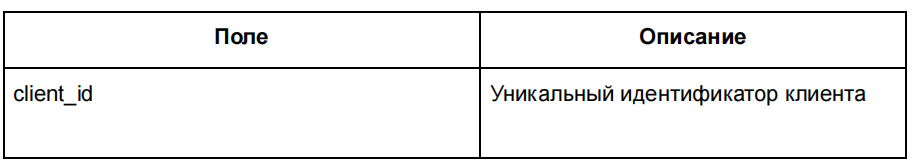
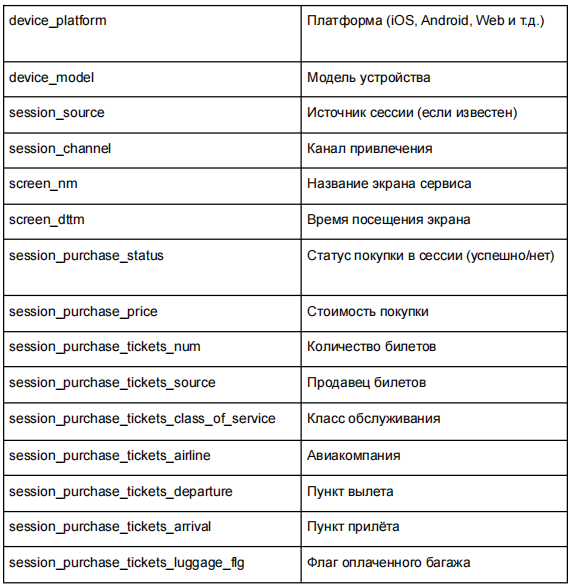

In [2]:
df = pd.read_excel('dataset.xlsx', date_parser='session_start_dt')
df.head()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15288\2059634424.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_excel('dataset.xlsx', date_parser='session_start_dt')


,session_start_dt,device_platform,client_start_year,client_id,session_id,session_source,session_channel,screen_nm,screen_dttm,client_avia_user_start_year,...,client_gmv,session_purchase_price,session_purchase_tickets_num,session_purchase_tickets_sourse,session_purchase_status,session_purchase_tickets_airline,session_purchase_tickets_departure,session_purchase_tickets_arrival,session_purchase_tickets_luggage_flg,session_purchase_tickets_class_of_service
0,2025-08-11,android,2022.0,1ced90f0cbf7673a49e1f06035a20c2d31bd2876e768f2...,168e64115c5eb71efa3f2ffb59a38a04f182540de70312...,Контент-каналы,Сторис,Оффер,2025-08-11 13:05:44.638,2025,...,27427.476667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-10,ios,2016.0,707572ff842ece6fd9c6ab59c5f7d7309de18ae153995b...,a1e18971d51f0e7699396daa17b8373dd2bddec4ffa2da...,Неизвестно,Неизвестно,Оффер,2025-04-10 23:55:10.936,2024,...,72363.028889,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-06-05,ios,2025.0,514278f8446c5920e20faddc6aa5b03cc8fa784aa9be9a...,f29b5c0c7391fb9aee4bb47d9dab77d1161e1eec5b108f...,SEO,Bing,Выдача,2025-06-05 10:23:44.627,2025,...,6645.640000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-02-18,android,2022.0,d42de563a20cd93b6218c5eab57aac2f62e8a6ffaec3d1...,9abb7f52910e38152f4e261157fd4435534dbf7273f080...,SEO,Яндекс,Поиск,2025-02-18 15:21:08.491,2024,...,3543.480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-09-01,ios,2022.0,fb3597c695c46ebe63eb6f8ff9e89b7cd0fc74a6c309fe...,a6a3488345af3d422b8bf2b11c14f1aa75c4829c606179...,Неизвестно,Неизвестно,Выдача,2025-09-01 11:35:23.627,2024,...,22816.832000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


0. Сперва изучим поступившие данные, уберем пропуски и дубликаты.

In [57]:
print(df.isna().sum())

session_start_dt                                  0
device_platform                                 211
client_start_year                                45
client_id                                         0
session_id                                        0
session_source                                    0
session_channel                                   0
screen_nm                                         0
screen_dttm                                       0
client_avia_user_start_year                       0
client_segment                                    0
client_avia_orders                                0
client_gmv                                        0
session_purchase_price                       241556
session_purchase_tickets_num                 241556
session_purchase_tickets_sourse              241723
session_purchase_status                      241723
session_purchase_tickets_airline             241723
session_purchase_tickets_departure           241723
session_purc

In [58]:
df.shape

(244345, 22)

In [3]:
df = df.drop_duplicates()
df['session_purchase_status'] = df['session_purchase_status'].fillna('Неуспешные')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244345 entries, 0 to 244344
Data columns (total 22 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   session_start_dt                           244345 non-null  object 
 1   device_platform                            244134 non-null  object 
 2   client_start_year                          244300 non-null  float64
 3   client_id                                  244345 non-null  object 
 4   session_id                                 244345 non-null  object 
 5   session_source                             244345 non-null  object 
 6   session_channel                            244345 non-null  object 
 7   screen_nm                                  244345 non-null  object 
 8   screen_dttm                                244345 non-null  object 
 9   client_avia_user_start_year                244345 non-null  int64  
 10  client_s

In [60]:
df.shape

(244345, 22)

In [61]:
df['session_start_dt'].min(), df['session_start_dt'].max()

('2025-01-01', '2025-09-30')

1. Задание 1 - Сформулировать продуктовые гипотезы

1.1. Построить Customer Journey Map сценария заказа

| Характеристики\Этап | Выдача | Поиск | Оффер | Чекаут | Покупка бэк | Покупка фронт |
|---------------------|--------|-------|-------|--------|-------------|---------------|
|Действия пользователя|Пользователь переход по ссылке, открывается страница сервиса, на которой отображаются популярные направления перелетов и фильтры для поиска|Пользователь нажимает на фильтры и выбирает необходимые параметры поиска|После нажатия "Поиск" сервис предлагает авиабилеты с релевантными параметрами, по возможности сортируя от наиболее релевантных к наименее|Пользователь выбирает понравившийся авиабилет и переходит к оформлению|Пользователь заполняет данные о себе и багаже (если он есть)|Приобретение билета пользователем|
|Точки взаимодействия с платформой|Пользователь может прокручивать страницу и смотреть на предложения о наиболее популярных направлениях, может нажать на одно из них для перехода к стадии Чекаут|Взаимодействия пользователя с фильтрами|Пользователь может прокручивать страницу с релевантными предложениями и выбрать одно из них|Нажатие на кнопку "Ознакомиться" или "Перейти к оформлению"|Заполнение данных в поля (ФИО, паспорт, багаж и пр.)|Приобретение билета банковской картой пользователя, данные которой он вбивает на сайте, затем получение квитации об оплате|
|Возможные боли|1. Пользователю может быть непонятен контент стартовой страницы 2. Визуально непривлекательный интерфейс 3. Сложность нахождения параметров поиска|1. Несодержательные фильтры 2. Большое количество фильтров 3. Отсутствие необходимого фильтра|1. Предложение нерелевантных вариантов выбора 2. Плохая сортировка по релевантности|1. Отсутствие базовой информации о полете (откуда куда, стоимость, класс, базовые услуги)|1. Отсутствие подсказок по заполнению 2. Отстутствие необходимых полей заполнения (наличие питомца, багажа) 3.|1. Несовпадение цен на этапе "Чекаут" и "Покупка фронт"|
|Метрики для измерения эффективности этапа|1. Кф ухода со стартовой страницы 2. Время до первого взаимодействия (переход к другому этапу)|1. Кф завершенного поиска 2. Частота использования каждого фильтра|1. CTR по выданным билетам 2. Время на странице|1. Конверсия 2. Доля возвратов на предыдущий этап|1. % пользователей, завершивших заполнение и перешедших на след. этап 2. Время заполнения формы|1. Кф успешных оплат 2. Расхождение цен|

1.2. Определить главную метрику для бизнеса (компании N) - NSM

Ключевая метрика для бизнеса - Конверсия в покупку, так как бизнесу важно,\
чтобы пользователь проходил путь до покупки билета полностью. Больший процент \
покупателей свидетельствует о качественном и удобном процессе приобретения. 

1.3. Выдвинуть 2 продуктовые гипотезы для роста NSM

Для выдвижения гипотез необходимо посмотреть на проблемы у бизнеса M (Авиасейлс). Проведем EDA

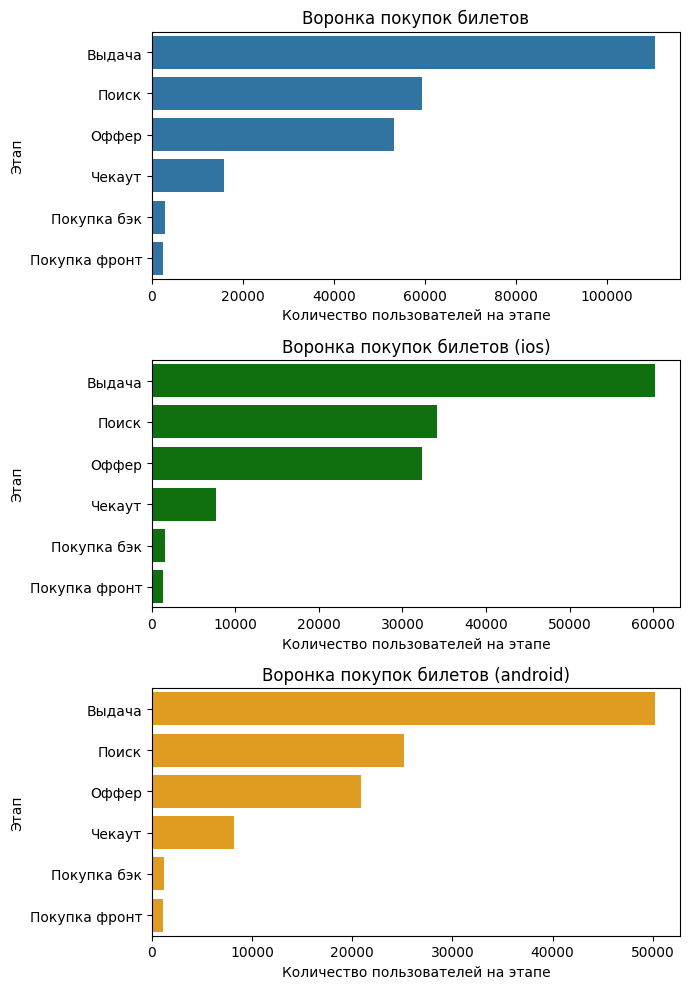

In [87]:
plt.figure(figsize=(7, 10))

plt.subplot(3, 1, 1)
plt.title('Воронка покупок билетов')
sns.barplot(df.groupby('screen_nm')['device_platform'].agg('count').sort_values(ascending=False), orient='h')
plt.xlabel('Количество пользователей на этапе')
plt.ylabel('Этап')

plt.subplot(3, 1, 2)
plt.title('Воронка покупок билетов (ios)')
sns.barplot(df[df['device_platform'] == 'ios'].groupby('screen_nm')['device_platform'].agg('count').sort_values(ascending=False), orient='h', color='green')
plt.xlabel('Количество пользователей на этапе')
plt.ylabel('Этап')

plt.subplot(3, 1, 3)
plt.title('Воронка покупок билетов (android)')
sns.barplot(df[df['device_platform'] == 'android'].groupby('screen_nm')['device_platform'].agg('count').sort_values(ascending=False), orient='h', color='orange')
plt.xlabel('Количество пользователей на этапе')
plt.ylabel('Этап')

plt.tight_layout()
plt.show()

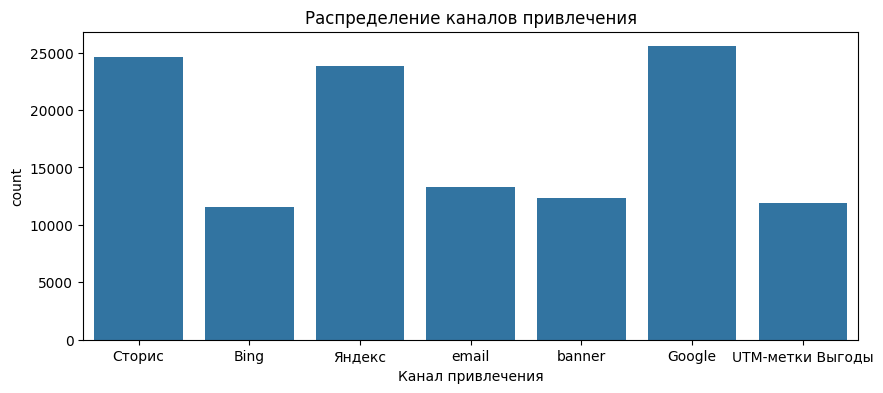

In [ ]:
plt.figure(figsize=(10,4))
plt.title('Распределение каналов привлечения')
sns.countplot(data=df[df['session_channel'] != 'Неизвестно'], x='session_channel')
plt.xlabel('Канал привлечения')
plt.show()

In [95]:
ct = pd.crosstab(df['session_channel'], df['session_purchase_status'])
ct['Доля успешных'] = ct['Успешные'] / (ct['Успешные'] + ct['Неуспешные']) * 100
ct

session_purchase_status,Неуспешные,Успешные,Доля успешных
session_channel,,,
Bing,11421,125,1.082626
Google,25242,290,1.135830
UTM-метки Выгоды,11797,133,1.114837
banner,12221,151,1.220498
email,13153,140,1.053186
Неизвестно,119930,1306,1.077238
Сторис,24351,246,1.000122
Яндекс,23608,231,0.969000


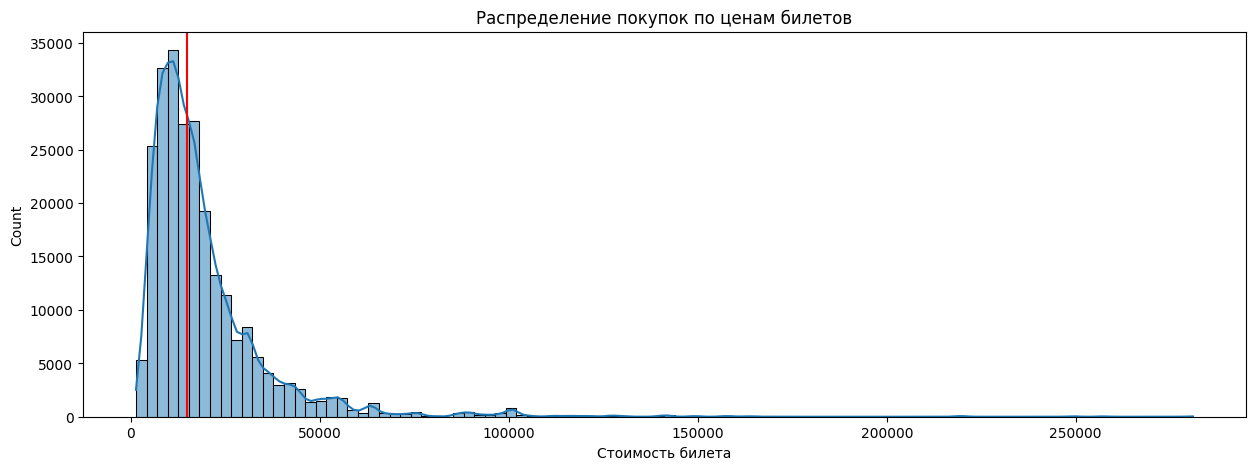

In [6]:
plt.figure(figsize=(15, 5))
plt.title('Распределение покупок по ценам билетов')
sns.histplot(df, x='client_gmv', kde=True, bins=100)
plt.axvline(df['client_gmv'].median(), color='red')
plt.xlabel('Стоимость билета')
plt.show()

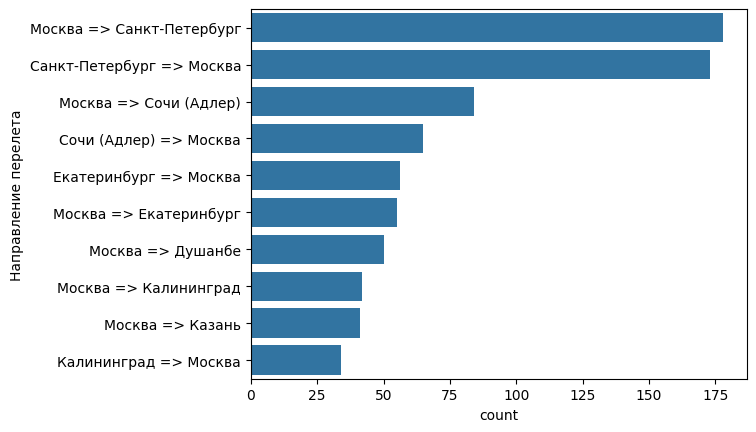

In [62]:
df['Направление перелета'] = df['session_purchase_tickets_departure'] + ' => ' +df['session_purchase_tickets_arrival']
df['Направление перелета'].value_counts()

sns.barplot(df['Направление перелета'].value_counts()[:10],orient='h')
plt.show()

In [99]:
df['Месяц_no'] = pd.to_datetime(df['session_start_dt']).dt.month
df['Месяц'] = pd.to_datetime(df['session_start_dt']).dt.month_name()

gb = df.groupby(['Месяц_no', 'Месяц'])['session_purchase_price'].sum()
print(gb)

Месяц_no  Месяц    
1         January      6244730.37
2         February     4180361.96
3         March        4961693.26
4         April        4276611.97
5         May          4787507.68
6         June         4316656.24
7         July         1531090.73
8         August       5874889.62
9         September    4004747.89
Name: session_purchase_price, dtype: float64


Выводы по EDA:
1. Воронка покупок билетов показывает, что Пользователь прекращает приобретение билетов на \
этапе "Оффер" -> "Чекаут" -> "Покупка бэк". Опираясь на CJM, можно предположить, что такое \
падение конверсии объясняется плохим подбором предложений от сервиса, отсутствием базовой информации \
о перелете, а также неудобством заполнения данных уже на этапе приобретения билета. \
Что также интересно, падение конверсии наиболее резкое у пользователей на платформе ios, чем на android.

2. Видим, что наилучшей платформой для привлечения являются Google, Сторис и Яндекс. Наименьшее количество \
пользователей пришло из Bing (возможно в виду непопулярности платформы в России), Баннеры. Однако, несмотря \
на малое привлечение через баннеры, наибольший процент успешно приобретенных билетов именно у них (1.22%).

3. Стоит отметить, что медианный чек билета составляет 15-20 тыс. руб. При этом, наиболее частые направления \
перелетов - это Москва-СПБ, Москва-Сочи, Москва-Екб и Москва-Душанбе (единственное зарубежное направление в топ 10).

4. Выручка Компании M стабильная на протяжении всего периода с 1 января по 30 сентября 2025 года, \
составляет 4-6 млн. р. Исключение составляет месяц Июль, где выручка оказалась аномально низкой - всего 1,5 млн. р. \
На основе имеющихся данных о компании нельзя сделать вывод о причине такой ситуации. Возможно, был сбой в системе.\
Наблюдается сезонность: зимой и в конце лета выручка заметно растет.


1.3. Выдвижение гипотез по улучшению

Гипотеза 1: Если информировать клиента о базовой цене и цене с багажом, то конверсия в покупку вырастет на 4%, \
потому что вырастет лояльность клиентов к компании из-за честности цены.

Гипотеза 2: Если снизить цену билета на 10% от цены на билет, то конверсия вырастет на 15%, потому что вырастет количество проданных билетов.


|Сетапп теста|Описание|
|-|-|
|Основная гипотеза H0|Конверсия в покупку не изменится|
|MDE|ожидаемая конверсия - базовая|
|Размер выборки|Выборки одинакового размера, Общее число в одной выборке должно быть не меньше $$ \frac {(Z_(alpha/2) + Z_(beta))^2 * (p1 * (1-p1) + p2*(1-p2))} { MDE^2} $$ |
|Формирование выборок|Выборки должны быть сформированы со стратификацией по платформе, чтобы сохранить распределение по типу устройства|
|Длительность теста|Размер выборки / Плотность потока|
|Тест|Z-тест, так как метрика относительная и по ЦПТ средняя величина стремится к нормальному распределению|
|Сколько принесет компании?|Так как компания N - банк, то ей выгодно брать процент комиссии с продажи билета при приобретении билета картой нашего банка. |

**Итоговое решение нашей компании N о сотрудничестве с компанией M: Да, сотрудничать стоит, поскольку заметен\
потенциал развития и неплохое экономическое положение компании M на рынке.**